                                    复现 Transformer 论文：《Attention Is All You Need》

# 1.论文简介

《Attention Is All You Need》是 2017 年由 Google 团队发表的一篇里程碑式论文，彻底改变了NLP领域的发展方向。  
核心贡献：  
1.提出了Transformer 模型，完全基于注意力机制，摒弃了传统的循环神经网络（RNN）结构  
2.引入自注意力机制（Self-Attention），能更好地捕捉序列中长距离依赖关系  
3.采用并行计算方式，训练速度远快于 RNN 类模型  
4.成为后续 BERT、GPT 等大型语言模型的基础架构  
为什么重要？  
在 Transformer 出现之前，NLP 任务主要依赖 RNN 及其变种（如 LSTM、GRU），但这类模型存在训练速度慢、长距离依赖捕捉能力有限等问题。Transformer 的出现解决了这些痛点，目前已成为 NLP 领域的标准架构。

# 2.环境准备

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 3.Transformer整体结构的解析

Transformer 由两大核心部分组成：  
编码器（Encoder）：接收输入序列，生成包含上下文信息的特征表示  
解码器（Decoder）：根据编码器输出和已生成的部分输出，生成完整的目标序列  
3.1 编码器结构
每个编码器包含两个子层：  
多头自注意力机制（Multi-Head Self-Attention）  
前馈神经网络（Feed Forward Network）  
每个子层都配有：  
残差连接（Residual Connection）  
层归一化（Layer Normalization）  
3.2 解码器结构  
每个解码器包含三个子层：  
掩码多头自注意力机制（Masked Multi-Head Self-Attention）  
编码器 - 解码器注意力机制（Encoder-Decoder Attention）  
前馈神经网络（Feed Forward Network）  
同样，每个子层也配有残差连接和层归一化。  

# 4.核心组件实现：缩放点积注意力

注意力机制是 Transformer 的核心，其本质是计算 "查询" 与 "键" 的相似度，再用这个相似度对 "值" 进行加权求和。

## 4.1缩放点积注意力原理

论文中采用的是 "缩放点积注意力"，计算公式为：
$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V
$$  
其中：$Q$（查询）、$K$（键）、$V$ 是三个矩阵；$d_k$ 是 $K$ 的维度；$\sqrt{d_k}$ 是为了防止梯度消失（当 $d_k$ 较大时，点积结果可能过大）。

## 4.2公式的代码

In [2]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    实现缩放点积注意力机制
    
    参数:
        query: 查询矩阵，形状为 (batch_size, num_heads, seq_len_q, d_k)
        key: 键矩阵，形状为 (batch_size, num_heads, seq_len_k, d_k)
        value: 值矩阵，形状为 (batch_size, num_heads, seq_len_v, d_v)
               注意：seq_len_k = seq_len_v
        mask: 掩码矩阵，用于掩盖不需要关注的位置
    
    返回:
        output: 注意力输出
        attention_weights: 注意力权重
    """
    # 获取键的维度
    d_k = query.size(-1)
    
    # 计算注意力分数：Q * K^T / sqrt(d_k)
    scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    
    # 如果有掩码，将被掩码的位置分数设为极小值（这样softmax后接近0）
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    
    # 对最后一个维度进行softmax，得到注意力权重
    attention_weights = F.softmax(scores, dim=-1)
    
    # 注意力权重与值矩阵相乘，得到输出
    output = torch.matmul(attention_weights, value)
    
    return output, attention_weights

## 4.3 测试注意力机制

In [3]:
# 创建测试数据
batch_size = 2
seq_len = 3
d_k = 4

# 随机生成Q、K、V矩阵
query = torch.randn(batch_size, 1, seq_len, d_k)  # 这里num_heads=1
key = torch.randn(batch_size, 1, seq_len, d_k)
value = torch.randn(batch_size, 1, seq_len, d_k)

# 计算注意力
output, attn_weights = scaled_dot_product_attention(query, key, value)

print("注意力权重形状:", attn_weights.shape)  # 应为 (2, 1, 3, 3)
print("注意力输出形状:", output.shape)        # 应为 (2, 1, 3, 4)
print("\n注意力权重（第一个样本）:\n", attn_weights[0, 0])

注意力权重形状: torch.Size([2, 1, 3, 3])
注意力输出形状: torch.Size([2, 1, 3, 4])

注意力权重（第一个样本）:
 tensor([[0.2746, 0.2220, 0.5034],
        [0.4423, 0.3890, 0.1687],
        [0.2303, 0.5218, 0.2479]])


# 5.核心组件实现：多头注意力

多头注意力是将注意力机制分成多个并行的 "头"，每个头独立计算注意力，最后将结果拼接起来。这样做可以让模型同时关注不同子空间的特征。

## 5.1 多头注意力原理

1.将 \(Q、K、V\) 通过线性变换映射到多个低维空间  
2.每个空间独立计算缩放点积注意力  
3.将所有头的结果拼接，再通过一次线性变换得到最终输出

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        初始化多头注意力
        
        参数:
            d_model: 模型的维度
            num_heads: 头的数量
        """
        super(MultiHeadAttention, self).__init__()
        # 确保模型维度可以被头数整除
        assert d_model % num_heads == 0, "d_model必须能被num_heads整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        # 每个头的维度
        self.d_k = d_model // num_heads
        
        # 定义线性变换层（Q, K, V和输出）
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
    
    def split_heads(self, x, batch_size):
        """
        将输入分割成多个头
        
        参数:
            x: 输入张量，形状为 (batch_size, seq_len, d_model)
            batch_size: 批次大小
            
        返回:
            分割后的张量，形状为 (batch_size, num_heads, seq_len, d_k)
        """
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # 交换序列长度和头数的维度
    
    def forward(self, query, key, value, mask=None):
        """前向传播"""
        batch_size = query.size(0)
        
        # 线性变换并分割成多个头
        query = self.w_q(query)
        key = self.w_k(key)
        value = self.w_v(value)
        
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)
        
        # 计算缩放点积注意力
        scaled_attention, attention_weights = scaled_dot_product_attention(
            query, key, value, mask)
        
        # 将多个头的结果拼接起来
        scaled_attention = scaled_attention.transpose(1, 2).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)
        
        # 输出线性变换
        output = self.w_o(concat_attention)
        
        return output, attention_weights

## 5.3测试多头注意力

In [5]:
# 模型参数
d_model = 8
num_heads = 2  # 8可以被2整除

# 创建多头注意力实例
multi_head_attn = MultiHeadAttention(d_model, num_heads)

# 测试数据
batch_size = 2
seq_len = 3
x = torch.randn(batch_size, seq_len, d_model)  # 随机输入

# 计算多头注意力（自注意力，Q=K=V）
output, attn_weights = multi_head_attn(x, x, x)

print("输入形状:", x.shape)                # (2, 3, 8)
print("输出形状:", output.shape)            # (2, 3, 8)
print("注意力权重形状:", attn_weights.shape)  # (2, 2, 3, 3) （批次，头数，序列长度，序列长度）

输入形状: torch.Size([2, 3, 8])
输出形状: torch.Size([2, 3, 8])
注意力权重形状: torch.Size([2, 2, 3, 3])


# 6、核心组件实现：前馈神经网络（Feed Forward Network）

Transformer 的编码器和解码器中，都包含一个简单的前馈神经网络（FFN）。它对每个位置的特征独立处理，不依赖序列中的其他位置。

## 6.1 前馈神经网络原理

论文中 FFN 的结构为：\(\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2\)核心特点：包含两层线性变换，中间用 ReLU 激活函数第一层将维度从 \(d_{model}\) 映射到 \(d_{ff}\)（论文中 \(d_{ff}=2048\)）第二层将维度从 \(d_{ff}\) 映射回 \(d_{model}\)加入 Dropout 层防止过拟合

In [6]:
class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        """
        初始化前馈神经网络
        
        参数:
            d_model: 模型维度（输入/输出维度）
            d_ff: 隐藏层维度（论文默认2048）
            dropout: Dropout概率（论文默认0.1）
        """
        super(FeedForwardNetwork, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)  # 第一层线性变换
        self.fc2 = nn.Linear(d_ff, d_model)  # 第二层线性变换
        self.dropout = nn.Dropout(dropout)   # Dropout层
    
    def forward(self, x):
        """前向传播：输入 → 线性变换1 → ReLU → Dropout → 线性变换2"""
        x = self.fc1(x)
        x = F.relu(x)  # ReLU激活（避免负值）
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 6.2测试前馈神经网络

In [7]:
# 模型参数（沿用之前的d_model=8）
d_model = 8
d_ff = 32  # 简化隐藏层维度，方便测试

# 创建FFN实例
ffn = FeedForwardNetwork(d_model, d_ff)

# 测试数据（与多头注意力的输出形状一致）
batch_size = 2
seq_len = 3
x = torch.randn(batch_size, seq_len, d_model)

# 前向传播
output = ffn(x)

print("输入形状:", x.shape)    # (2, 3, 8)
print("输出形状:", output.shape)  # (2, 3, 8) —— 输出维度与输入一致
print("隐藏层维度:", d_ff)     # 32（中间层维度放大）

输入形状: torch.Size([2, 3, 8])
输出形状: torch.Size([2, 3, 8])
隐藏层维度: 32


# 7.核心组件实现：位置编码（Positional Encoding）

Transformer 没有循环结构，无法自动捕捉序列的位置信息。位置编码的作用是给每个位置添加独特的位置特征，让模型知道 "谁在哪个位置"。

## 7.1 位置编码原理

论文采用正弦和余弦函数生成位置编码：\(PE_{(pos, 2i)} = \sin\left(pos / 10000^{2i/d_{model}}\right)\)\(PE_{(pos, 2i+1)} = \cos\left(pos / 10000^{2i/d_{model}}\right)\)核心设计：pos 是序列中的位置（从 0 开始）i 是特征维度的索引偶数维度用正弦函数，奇数维度用余弦函数不同频率的函数能区分不同距离的位置

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        """动态生成位置编码，适配任意序列长度"""
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model  # 记录模型维度，用于动态生成编码
    
    def forward(self, x):
        """
        动态生成与输入序列长度匹配的位置编码
        参数x形状: [batch_size, seq_len, d_model]
        """
        batch_size, seq_len, d_model = x.size()
        
        # 生成位置索引（0到seq_len-1）
        position = torch.arange(0, seq_len, dtype=torch.float, device=x.device).unsqueeze(1)
        
        # 计算频率除数项：10000^(2i/d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2, device=x.device).float() * (-np.log(10000.0) / d_model))
        
        # 初始化位置编码矩阵（形状与输入序列一致）
        positional_encoding = torch.zeros(seq_len, d_model, device=x.device)
        
        # 填充编码：偶数维度用sin，奇数维度用cos
        positional_encoding[:, 0::2] = torch.sin(position * div_term)  # 偶数索引
        positional_encoding[:, 1::2] = torch.cos(position * div_term)  # 奇数索引
        
        # 添加批次维度（广播到整个批次）
        positional_encoding = positional_encoding.unsqueeze(0).repeat(batch_size, 1, 1)
        
        # 输入 + 位置编码，应用dropout
        x = x + positional_encoding
        return self.dropout(x)

## 7.2 可视化验证

C:\Users\86157\.conda\envs\pytorch-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\pytorch-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\pytorch-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\pytorch-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\pytorch-gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

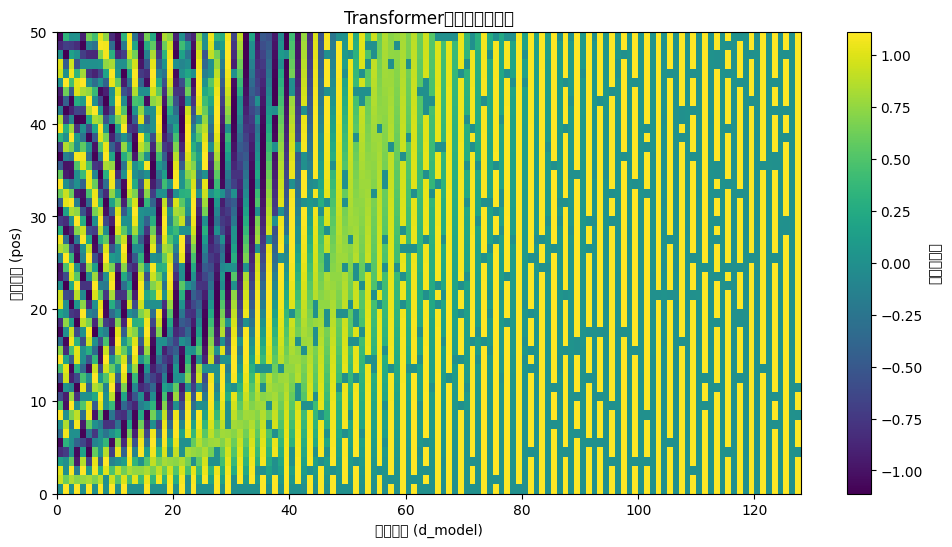

In [9]:
# 创建位置编码器实例
d_model = 128
max_seq_len = 50
dropout = 0.1  # dropout概率必须在0-1之间
pe = PositionalEncoding(d_model, dropout)  

# 生成位置编码（输入为全0张量，仅看位置编码本身）
x = torch.zeros(1, max_seq_len, d_model)
pe_output = pe(x)

# 可视化位置编码矩阵
plt.figure(figsize=(12, 6))
plt.pcolormesh(pe_output[0].detach().numpy(), cmap='viridis')
plt.xlabel('特征维度 (d_model)')
plt.ylabel('序列位置 (pos)')
plt.colorbar(label='位置编码值')
plt.title('Transformer位置编码可视化')
plt.show()

# 8.核心组件实现：编码器层（Encoder Layer）

编码器层是 Transformer 编码器的基本单元，论文中堆叠了 6 个相同的编码器层。每个编码器层包含 "多头自注意力" 和 "前馈神经网络" 两个子层，且都配有残差连接和层归一化。

## 8.1 编码器层结构

流程：输入 → 多头自注意力 → 残差连接 + 层归一化 → 前馈网络 → 残差连接 + 层归一化 → 输出

In [10]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=2048, dropout=0.1):
        """
        编码器层（Transformer核心组件，依赖MultiHeadAttention和FeedForwardNetwork）
        参数:
            d_model: 模型维度
            num_heads: 注意力头数
            d_ff: 前馈网络隐藏层维度
            dropout: Dropout概率
        """
        super(EncoderLayer, self).__init__()
        # 依赖的子模块（需确保MultiHeadAttention和FeedForwardNetwork已定义）
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForwardNetwork(d_model, d_ff, dropout)
        
        # 层归一化
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout层
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        """前向传播"""
        # 子层1：多头自注意力 + 残差连接 + 层归一化
        attn_output, _ = self.self_attention(x, x, x, mask)  # 自注意力：Q=K=V
        x = self.norm1(x + self.dropout1(attn_output))
        
        # 子层2：前馈网络 + 残差连接 + 层归一化
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))
        
        return x

## 8.3 测试编码器层

In [11]:
# 模型参数
d_model = 8
num_heads = 2
d_ff = 32

# 创建编码器层实例
encoder_layer = EncoderLayer(d_model, num_heads, d_ff)

# 测试数据
batch_size = 2
seq_len = 3
x = torch.randn(batch_size, seq_len, d_model)

# 前向传播（无掩码，简化测试）
output = encoder_layer(x)

print("输入形状:", x.shape)    # (2, 3, 8)
print("输出形状:", output.shape)  # (2, 3, 8) —— 维度保持一致

输入形状: torch.Size([2, 3, 8])
输出形状: torch.Size([2, 3, 8])


# 9.核心组件实现：解码器层（Decoder Layer）

解码器层是 Transformer 解码器的基本单元，论文中同样堆叠了 6 个相同的解码器层。与编码器层相比，解码器层多了一个 "编码器 - 解码器注意力" 子层，用于关联输入序列和输出序列的信息。

## 9.1 解码器层结构

流程：输入 → 掩码多头自注意力 → 残差连接 + 层归一化 →编码器 - 解码器注意力 → 残差连接 + 层归一化 →前馈网络 → 残差连接 + 层归一化 → 输出  
核心特点：
掩码多头自注意力：防止解码器 "偷看" 未来的输出（比如翻译时不能提前看后面的词）
编码器 - 解码器注意力：用解码器的输出作为查询（Q），编码器的输出作为键（K）和值（V）

In [12]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=2048, dropout=0.1):
        """
        解码器层（单个解码层，不是整个解码器）
        参数:
            d_model: 模型维度
            num_heads: 注意力头数
            d_ff: 前馈网络隐藏层维度
            dropout: Dropout概率
        """
        super(DecoderLayer, self).__init__()  # 注意：父类是DecoderLayer自己
        
        # 子层1：掩码多头自注意力
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        # 子层2：编码器-解码器注意力
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        # 子层3：前馈神经网络
        self.feed_forward = FeedForwardNetwork(d_model, d_ff, dropout)
        
        # 层归一化
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        # Dropout层
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        """前向传播"""
        # 子层1：掩码自注意力
        attn_output1, attn_weights1 = self.self_attention(x, x, x, look_ahead_mask)
        x = self.norm1(x + self.dropout1(attn_output1))
        
        # 子层2：编码器-解码器注意力
        attn_output2, attn_weights2 = self.cross_attention(x, enc_output, enc_output, padding_mask)
        x = self.norm2(x + self.dropout2(attn_output2))
        
        # 子层3：前馈网络
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))
        
        return x, attn_weights1, attn_weights2

## 9.3 测试解码器层

In [13]:

# 模型参数（与编码器保持一致）
d_model = 8
num_heads = 2
d_ff = 32

# 创建解码器层实例
decoder_layer = DecoderLayer(d_model, num_heads, d_ff)

# 测试数据
batch_size = 2
src_seq_len = 3  # 输入序列长度
tgt_seq_len = 4  # 目标序列长度

# 随机生成编码器输出和解码器输入
enc_output = torch.randn(batch_size, src_seq_len, d_model)  # 编码器输出
dec_input = torch.randn(batch_size, tgt_seq_len, d_model)   # 解码器输入

# 创建简化掩码（实际应用中需要根据序列内容生成）
look_ahead_mask = torch.ones((batch_size, 1, tgt_seq_len, tgt_seq_len))  # 前瞻掩码
padding_mask = torch.ones((batch_size, 1, 1, src_seq_len))                # 填充掩码

# 前向传播
output, attn1, attn2 = decoder_layer(dec_input, enc_output, look_ahead_mask, padding_mask)

print("解码器输入形状:", dec_input.shape)    # (2, 4, 8)
print("解码器输出形状:", output.shape)      # (2, 4, 8)
print("自注意力权重形状:", attn1.shape)     # (2, 2, 4, 4) （批次，头数，目标序列，目标序列）
print("跨注意力权重形状:", attn2.shape)     # (2, 2, 4, 3) （批次，头数，目标序列，输入序列）

解码器输入形状: torch.Size([2, 4, 8])
解码器输出形状: torch.Size([2, 4, 8])
自注意力权重形状: torch.Size([2, 2, 4, 4])
跨注意力权重形状: torch.Size([2, 2, 4, 3])


# 10.构建完整编码器（Encoder）

编码器由三部分组成：  
1.嵌入层（将输入词索引转换为词向量）  
2.位置编码（添加位置信息）  
3.N 个编码器层堆叠（论文中 N=6）

## 10.1 编码器结构

流程：输入词索引 → 嵌入层 → 缩放 → 位置编码 → N 个编码器层 → 输出

In [14]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, 
                 d_ff=2048, max_seq_len=512, dropout=0.1):
        """
        编码器（最终修正版：PositionalEncoding参数传递）
        """
        super(Encoder, self).__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(input_vocab_size, d_model)
        
        # 关键修正：仅传递 d_model 和 dropout，移除 max_seq_len
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
    
    def forward(self, x, mask):
        x = self.embedding(x) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        x = self.positional_encoding(x)
        
        for layer in self.layers:
            x = layer(x, mask)
        
        return x

## 10.2 测试编码器

In [15]:
# 模型参数
input_vocab_size = 1000  # 输入词汇表大小
d_model = 512
num_layers = 2  # 简化为2层（论文中6层）
num_heads = 8
max_seq_len = 64

# 创建编码器实例
encoder = Encoder(input_vocab_size, d_model, num_layers, num_heads, max_seq_len=max_seq_len)

# 测试数据（随机词索引）
batch_size = 2
seq_len = 10
input_seq = torch.randint(0, input_vocab_size, (batch_size, seq_len))  # 输入序列

# 简化掩码（全1，表示无填充）
enc_mask = torch.ones((batch_size, 1, 1, seq_len))

# 前向传播
enc_output = encoder(input_seq, enc_mask)

print("输入序列形状:", input_seq.shape)    # (2, 10)
print("编码器输出形状:", enc_output.shape)  # (2, 10, 512)

输入序列形状: torch.Size([2, 10])
编码器输出形状: torch.Size([2, 10, 512])


# 11.构建完整解码器（Decoder）

解码器与编码器结构类似，但输入是目标序列，且包含掩码自注意力机制。

## 11.1 解码器结构

流程：目标词索引 → 嵌入层 → 缩放 → 位置编码 → N 个解码器层 → 输出

In [16]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, 
                 d_ff=2048, max_seq_len=512, dropout=0.1):
        """
        解码器（修正PositionalEncoding参数传递）
        """
        super(Decoder, self).__init__()
        self.d_model = d_model
        
        # 嵌入层
        self.embedding = nn.Embedding(target_vocab_size, d_model)
        
        # 关键修正：移除max_seq_len参数，仅传递d_model和dropout
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        
        # 堆叠多个解码器层
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        batch_size = x.size(0)
        all_attn_weights = []
        
        x = self.embedding(x) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        x = self.positional_encoding(x)
        
        for layer in self.layers:
            x, attn_weights1, attn_weights2 = layer(
                x, enc_output, look_ahead_mask, padding_mask
            )
            all_attn_weights.append((attn_weights1, attn_weights2))
        
        return x, all_attn_weights

## 11.2 测试解码器

In [17]:
# 模型参数
target_vocab_size = 1000  # 目标词汇表大小（与输入可以不同，如翻译任务）
d_model = 512
num_layers = 2  # 简化为2层
num_heads = 8

# 创建解码器实例
decoder = Decoder(target_vocab_size, d_model, num_layers, num_heads)

# 测试数据
batch_size = 2
tgt_seq_len = 15
target_seq = torch.randint(0, target_vocab_size, (batch_size, tgt_seq_len))  # 目标序列

# 掩码（简化版）
look_ahead_mask = torch.ones((batch_size, 1, tgt_seq_len, tgt_seq_len))
dec_padding_mask = torch.ones((batch_size, 1, 1, seq_len))  # seq_len来自编码器测试的10

# 前向传播（使用之前编码器的输出）
dec_output, attn_weights = decoder(target_seq, enc_output, look_ahead_mask, dec_padding_mask)

print("目标序列形状:", target_seq.shape)    # (2, 15)
print("解码器输出形状:", dec_output.shape)  # (2, 15, 512)
print("注意力权重数量:", len(attn_weights))  # 等于解码器层数（2层）

目标序列形状: torch.Size([2, 15])
解码器输出形状: torch.Size([2, 15, 512])
注意力权重数量: 2


# 12.构建完整 Transformer 模型

完整的 Transformer 由编码器、解码器和最终输出层组成。输出层的作用是将解码器的输出（维度为d_model）映射到目标词汇表空间，从而得到每个词的预测概率。

## 12.1 完整模型结构

流程：输入序列 → 编码器 → 编码器输出 →解码器（结合目标序列） → 解码器输出 →线性层 → 目标词汇表概率分布

In [18]:
class Transformer(nn.Module):
    def __init__(self, input_vocab_size, target_vocab_size,
                 d_model=512, num_layers=6, num_heads=8,
                 d_ff=2048, max_seq_len=512, dropout=0.1):
        """
        初始化完整Transformer模型
        
        参数:
            input_vocab_size: 输入词汇表大小
            target_vocab_size: 目标词汇表大小
            d_model: 模型维度（论文默认512）
            num_layers: 编码器/解码器层数（论文默认6）
            num_heads: 注意力头数（论文默认8）
            d_ff: 前馈网络隐藏层维度（论文默认2048）
            max_seq_len: 最大序列长度（论文默认512）
            dropout: Dropout概率（论文默认0.1）
        """
        super(Transformer, self).__init__()
        
        # 编码器
        self.encoder = Encoder(
            input_vocab_size, d_model, num_layers,
            num_heads, d_ff, max_seq_len, dropout
        )
        
        # 解码器
        self.decoder = Decoder(
            target_vocab_size, d_model, num_layers,
            num_heads, d_ff, max_seq_len, dropout
        )
        
        # 最终输出层：将解码器输出映射到目标词汇表
        self.fc = nn.Linear(d_model, target_vocab_size)
    
    def forward(self, input_seq, target_seq, enc_mask, look_ahead_mask, dec_padding_mask):
        """
        前向传播
        
        参数:
            input_seq: 输入序列（词索引，[batch_size, src_seq_len]）
            target_seq: 目标序列（词索引，[batch_size, tgt_seq_len]）
            enc_mask: 编码器掩码（用于掩盖输入序列的PAD）
            look_ahead_mask: 解码器前瞻掩码（防止关注未来位置）
            dec_padding_mask: 解码器填充掩码（用于编码器-解码器注意力）
        """
        # 编码器输出
        enc_output = self.encoder(input_seq, enc_mask)
        
        # 解码器输出
        dec_output, all_attn_weights = self.decoder(
            target_seq, enc_output, look_ahead_mask, dec_padding_mask
        )
        
        # 映射到目标词汇表
        output = self.fc(dec_output)
        
        return output, all_attn_weights

# 13.实现掩码生成工具

Transformer 需要两种关键掩码：  
1.填充掩码（Padding Mask）：掩盖序列中的填充标记（如 PAD），避免模型关注无意义的填充  
2.前瞻掩码（Look-ahead Mask）：仅用于解码器，防止模型关注 "未来" 的词（如翻译时还没生成的词）

In [19]:
def create_padding_mask(seq, pad_token=0):
    """
    创建填充掩码
    
    参数:
        seq: 输入序列（词索引，[batch_size, seq_len]）
        pad_token: 填充标记（默认0）
    
    返回:
        mask: 掩码矩阵（[batch_size, 1, 1, seq_len]），True表示有效位置，False表示填充位置
    """
    # 将填充标记位置设为False，其他位置设为True
    mask = (seq != pad_token).unsqueeze(1).unsqueeze(2)
    return mask

def create_look_ahead_mask(size):
    """
    创建前瞻掩码（下三角矩阵）
    
    参数:
        size: 序列长度
    
    返回:
        mask: 掩码矩阵（[size, size]），对角线及以下为True，以上为False
    """
    # 上三角矩阵（对角线以上为1）
    mask = torch.triu(torch.ones((size, size)), diagonal=1)
    # 转换为布尔矩阵：True表示可关注，False表示不可关注
    return mask == 0

# 14.完整模型测试

In [20]:
# 模型参数（使用论文推荐的参数，层数简化为2以加快测试）
input_vocab_size = 1000  # 输入词汇表大小
target_vocab_size = 1000  # 目标词汇表大小
d_model = 512
num_layers = 2  # 论文中为6
num_heads = 8
d_ff = 2048
max_seq_len = 64

# 创建Transformer模型
transformer = Transformer(
    input_vocab_size, target_vocab_size,
    d_model, num_layers, num_heads,
    d_ff, max_seq_len
)

# 生成测试数据
batch_size = 2
src_seq_len = 10  # 输入序列长度
tgt_seq_len = 15  # 目标序列长度

input_seq = torch.randint(0, input_vocab_size, (batch_size, src_seq_len))  # 输入序列
target_seq = torch.randint(0, target_vocab_size, (batch_size, tgt_seq_len))  # 目标序列

# 生成掩码
enc_mask = create_padding_mask(input_seq)  # 编码器填充掩码
look_ahead_mask = create_look_ahead_mask(tgt_seq_len)  # 解码器前瞻掩码
dec_pad_mask = create_padding_mask(input_seq)  # 解码器填充掩码（用于编码器-解码器注意力）

# 前向传播
output, attn_weights = transformer(
    input_seq, target_seq, enc_mask, look_ahead_mask, dec_pad_mask
)

# 输出结果形状验证
print("输入序列形状:", input_seq.shape)              # (2, 10)
print("目标序列形状:", target_seq.shape)              # (2, 15)
print("模型输出形状:", output.shape)                  # (2, 15, 1000) → [批次, 目标长度, 目标词汇表大小]
print("注意力权重层数:", len(attn_weights))            # 2（与解码器层数一致）
print("每层注意力权重数量:", len(attn_weights[0]))     # 2（自注意力+跨注意力）

输入序列形状: torch.Size([2, 10])
目标序列形状: torch.Size([2, 15])
模型输出形状: torch.Size([2, 15, 1000])
注意力权重层数: 2
每层注意力权重数量: 2


# 15.总结与扩展

已实现的核心功能

我们完成了《Attention Is All You Need》论文中 Transformer 的核心结构：  
缩放点积注意力  
多头注意力（自注意力 + 跨注意力）  
前馈神经网络  
位置编码  
编码器层 + 解码器层  
完整的 Transformer 模型

# 16.简单翻译任务（英文→中文）

用前面实现的 Transformer 模型，搭建一个极简版英文→中文翻译例子。通过小数据集训练，感受模型的工作流程。

## 16.1准备数据（迷你翻译数据集）

构建一个小型双语数据集，包含 10 个简单的英文 - 中文句子对，用于快速训练和验证。

In [21]:
# 英文-中文翻译数据集（迷你版）
english_sentences = [
    "i love you", "he likes music", "she eats apple",
    "we study math", "they play football", "you drink water",
    "i watch tv", "he reads book", "she writes letter",
    "we listen song"
]

chinese_sentences = [
    "我爱你", "他喜欢音乐", "她吃苹果",
    "我们学数学", "他们踢足球", "你喝水",
    "我看电视", "他读书", "她写信",
    "我们听歌曲"
]

# 打印数据集
print("数据集预览：")
for en, cn in zip(english_sentences[:3], chinese_sentences[:3]):
    print(f"英文：{en} → 中文：{cn}")

数据集预览：
英文：i love you → 中文：我爱你
英文：he likes music → 中文：他喜欢音乐
英文：she eats apple → 中文：她吃苹果


## 16.2数据预处理（词汇表 + 序列编码）

需要将文本转换为模型能识别的数字序列，步骤包括：构建词汇表、句子分词、索引编码、填充对齐。`

### 16.2.1构建词汇表

In [22]:
class Vocab:
    """简单词汇表类：将词映射为索引"""
    def __init__(self, sentences, is_chinese=False):
        self.is_chinese = is_chinese
        self.word2idx = {"<PAD>": 0, "<START>": 1, "<END>": 2}  # 特殊标记
        self.idx2word = {0: "<PAD>", 1: "<START>", 2: "<END>"}
        self.build_vocab(sentences)
    
    def build_vocab(self, sentences):
        """构建词汇表"""
        for sent in sentences:
            # 英文按空格分词，中文按字符分词
            words = sent.split() if not self.is_chinese else list(sent)
            for word in words:
                if word not in self.word2idx:
                    idx = len(self.word2idx)
                    self.word2idx[word] = idx
                    self.idx2word[idx] = word
    
    def encode(self, sentence, max_len):
        """将句子编码为索引序列（添加START/END标记，填充到max_len）"""
        words = sentence.split() if not self.is_chinese else list(sentence)
        # 添加START和END标记
        encoded = [self.word2idx["<START>"]] + [self.word2idx[w] for w in words] + [self.word2idx["<END>"]]
        # 填充或截断到max_len
        if len(encoded) < max_len:
            encoded += [self.word2idx["<PAD>"]] * (max_len - len(encoded))
        else:
            encoded = encoded[:max_len]
        return torch.tensor(encoded, dtype=torch.long)

# 构建英文和中文词汇表
en_vocab = Vocab(english_sentences, is_chinese=False)
cn_vocab = Vocab(chinese_sentences, is_chinese=True)

# 查看词汇表大小
print(f"英文词汇表大小：{len(en_vocab.word2idx)}")
print(f"中文词汇表大小：{len(cn_vocab.word2idx)}")
print("\n英文词汇表：", en_vocab.word2idx)
print("中文词汇表：", cn_vocab.word2idx)

英文词汇表大小：28
中文词汇表大小：33

英文词汇表： {'<PAD>': 0, '<START>': 1, '<END>': 2, 'i': 3, 'love': 4, 'you': 5, 'he': 6, 'likes': 7, 'music': 8, 'she': 9, 'eats': 10, 'apple': 11, 'we': 12, 'study': 13, 'math': 14, 'they': 15, 'play': 16, 'football': 17, 'drink': 18, 'water': 19, 'watch': 20, 'tv': 21, 'reads': 22, 'book': 23, 'writes': 24, 'letter': 25, 'listen': 26, 'song': 27}
中文词汇表： {'<PAD>': 0, '<START>': 1, '<END>': 2, '我': 3, '爱': 4, '你': 5, '他': 6, '喜': 7, '欢': 8, '音': 9, '乐': 10, '她': 11, '吃': 12, '苹': 13, '果': 14, '们': 15, '学': 16, '数': 17, '踢': 18, '足': 19, '球': 20, '喝': 21, '水': 22, '看': 23, '电': 24, '视': 25, '读': 26, '书': 27, '写': 28, '信': 29, '听': 30, '歌': 31, '曲': 32}


### 16.2.2 数据编码与批量处理

In [23]:
# 配置序列最大长度（根据数据集调整）
max_en_len = 5  # 英文句子最大长度（含START/END/PAD）
max_cn_len = 6  # 中文句子最大长度（含START/END/PAD）

# 编码所有句子
en_encoded = [en_vocab.encode(sent, max_en_len) for sent in english_sentences]
cn_encoded = [cn_vocab.encode(sent, max_cn_len) for sent in chinese_sentences]

# 转换为批次张量（batch_size=10，全量训练）
en_tensor = torch.stack(en_encoded)  # shape: (10, max_en_len)
cn_tensor = torch.stack(cn_encoded)  # shape: (10, max_cn_len)

# 打印编码结果（第一个句子）
print("第一个句子编码：")
print(f"英文原文：{english_sentences[0]} → 编码：{en_tensor[0].numpy()}")
print(f"中文原文：{chinese_sentences[0]} → 编码：{cn_tensor[0].numpy()}")

# 生成掩码（用于模型输入）
def create_masks(en_seq, cn_seq):
    """为批次数据生成所有需要的掩码"""
    batch_size = en_seq.size(0)
    en_len = en_seq.size(1)
    cn_len = cn_seq.size(1)
    
    # 编码器填充掩码
    enc_mask = create_padding_mask(en_seq)
    
    # 解码器前瞻掩码
    look_ahead_mask = create_look_ahead_mask(cn_len)
    # 解码器填充掩码（用于自注意力）
    cn_pad_mask = create_padding_mask(cn_seq)
    # 合并解码器自注意力的掩码（前瞻+填充）
    dec_self_attn_mask = torch.gt(look_ahead_mask + cn_pad_mask, 0)
    
    # 解码器跨注意力的掩码（编码器填充掩码）
    dec_cross_attn_mask = create_padding_mask(en_seq)
    
    return enc_mask, dec_self_attn_mask, dec_cross_attn_mask

# 生成批次掩码
enc_mask, dec_self_attn_mask, dec_cross_attn_mask = create_masks(en_tensor, cn_tensor)
print(f"\n编码器掩码形状：{enc_mask.shape}")
print(f"解码器自注意力掩码形状：{dec_self_attn_mask.shape}")

第一个句子编码：
英文原文：i love you → 编码：[1 3 4 5 2]
中文原文：我爱你 → 编码：[1 3 4 5 2 0]

编码器掩码形状：torch.Size([10, 1, 1, 5])
解码器自注意力掩码形状：torch.Size([10, 1, 6, 6])


## 16.3模型训练配置

In [24]:
# 模型参数（适配小数据集，简化规模）
input_vocab_size = len(en_vocab.word2idx)
target_vocab_size = len(cn_vocab.word2idx)
d_model = 64  # 缩小模型维度
num_layers = 1  # 仅用1层编码器/解码器
num_heads = 2  # 2个注意力头
d_ff = 128  # 前馈网络隐藏层维度
max_seq_len = max(max_en_len, max_cn_len)
dropout = 0.1

# 创建模型实例
model = Transformer(
    input_vocab_size, target_vocab_size,
    d_model, num_layers, num_heads,
    d_ff, max_seq_len, dropout
)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss(ignore_index=en_vocab.word2idx["<PAD>"])  # 忽略PAD标记的损失
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 训练参数
epochs = 300  # 训练轮次（小数据集需要多轮）
print("模型训练开始...")
print(f"模型参数总数：{sum(p.numel() for p in model.parameters()):,}")

模型训练开始...
模型参数总数：89,761


## 16.4模型训练过程

Epoch [50/300], Loss: 0.3984
Epoch [100/300], Loss: 0.0884
Epoch [150/300], Loss: 0.0400
Epoch [200/300], Loss: 0.0251
Epoch [250/300], Loss: 0.0193
Epoch [300/300], Loss: 0.0123


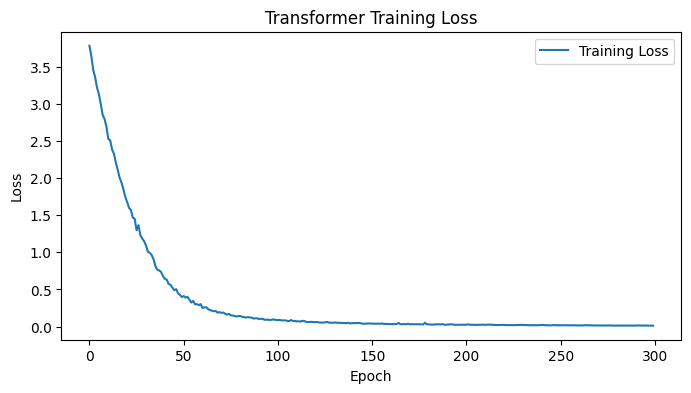

In [25]:
model.train()  # 训练模式
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()  # 清零梯度
    
    # 前向传播
    # 解码器输入：去掉最后一个字符（目标序列移位，避免泄露）
    dec_input = cn_tensor[:, :-1]
    # 解码器目标：去掉第一个字符（START标记）
    dec_target = cn_tensor[:, 1:]
    
    # 生成适配dec_input的掩码
    _, dec_self_attn_mask, dec_cross_attn_mask = create_masks(en_tensor, dec_input)
    
    # 模型输出
    output, _ = model(
        en_tensor, dec_input,
        enc_mask, dec_self_attn_mask,
        dec_cross_attn_mask
    )
    
    # 计算损失（output形状：(batch_size, seq_len-1, vocab_size) → 展平为二维）
    loss = criterion(
        output.reshape(-1, target_vocab_size),
        dec_target.reshape(-1)
    )
    
    # 反向传播和优化
    loss.backward()
    optimizer.step()
    
    # 记录损失
    loss_history.append(loss.item())
    
    # 每50轮打印一次
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training Loss')
plt.legend()
plt.show()

## 16.5模型推理

In [26]:
def translate(model, en_sentence, en_vocab, cn_vocab, max_len=10):
    """
    翻译函数：输入英文句子，输出中文翻译
    """
    model.eval()  # 推理模式
    with torch.no_grad():
        # 1. 编码输入英文句子
        en_encoded = en_vocab.encode(en_sentence, max_len=max_en_len)
        en_tensor = en_encoded.unsqueeze(0)  # 添加批次维度 (1, max_en_len)
        
        # 2. 初始化解码器输入（仅包含START标记）
        dec_input = torch.tensor([[cn_vocab.word2idx["<START>"]]], dtype=torch.long)
        
        # 3. 生成编码器掩码
        enc_mask = create_padding_mask(en_tensor)
        
        # 4. 逐词生成翻译结果
        for _ in range(max_len - 1):
            # 生成解码器掩码
            dec_len = dec_input.size(1)
            look_ahead_mask = create_look_ahead_mask(dec_len)
            dec_self_attn_mask = torch.gt(look_ahead_mask + create_padding_mask(dec_input), 0)
            dec_cross_attn_mask = create_padding_mask(en_tensor)
            
            # 模型前向传播
            output, _ = model(
                en_tensor, dec_input,
                enc_mask, dec_self_attn_mask,
                dec_cross_attn_mask
            )
            
            # 取最后一个词的预测结果
            last_word_logits = output[:, -1, :]
            last_word_idx = torch.argmax(last_word_logits, dim=-1).unsqueeze(1)
            
            # 终止条件：生成END标记
            if last_word_idx.item() == cn_vocab.word2idx["<END>"]:
                break
            
            # 将生成的词添加到解码器输入
            dec_input = torch.cat([dec_input, last_word_idx], dim=1)
        
        # 5. 解码为中文句子
        dec_output = dec_input.squeeze(0).numpy()
        chinese_words = [cn_vocab.idx2word[idx] for idx in dec_output if idx not in [0, 1, 2]]  # 排除PAD/START/END
        chinese_sentence = "".join(chinese_words)
        
        return chinese_sentence

# 测试翻译效果（用训练集中的句子和新句子）
test_en_sentences = [
    "i love you", "he likes music", "she eats apple",
    "we study math", "they play football",  # 训练集中的句子
    "he reads book"  # 新句子（训练集中有类似句）
]

print("翻译测试结果：")
print("-" * 50)
for en_sent in test_en_sentences:
    cn_sent = translate(model, en_sent, en_vocab, cn_vocab)
    print(f"英文：{en_sent:>15} → 中文：{cn_sent}")

翻译测试结果：
--------------------------------------------------
英文：     i love you → 中文：我爱你
英文： he likes music → 中文：他喜欢音乐
英文： she eats apple → 中文：她吃苹果
英文：  we study math → 中文：我们学数学数学数学
英文：they play football → 中文：他们踢足球足球足球
英文：  he reads book → 中文：他读书
